## Simple Moving Average Model for win-loss outcomes

In [16]:
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit



In [1]:
def historical_average(data, window):
    """
    Calculates the simple moving average for binary outcomes.

    Args:
        data (pd.Series): A pandas Series containing binary (0 or 1) outcomes.
        window (int): The size of the historical window for the moving average.

    Returns:
        pd.Series: A Series containing the moving average probabilities.
    """
    return data.rolling(window=window).mean()

# Assuming 'binary_data' is a pandas Series of 0s and 1s
# binary_data = pd.Series([0, 1, 0, 1, 1, 0, 1, 0, 1, 1])
# probabilities = historical_average_binary(binary_data, window=3)
# print(probabilities)

In [3]:
def predict_binary_from_probability(probabilities, threshold=0.5):
    """
    Converts probabilities to binary predictions based on a threshold.

    Args:
        probabilities (pd.Series): A Series of probabilities (between 0 and 1).
        threshold (float): The threshold for binary classification.

    Returns:
        pd.Series: A Series containing binary predictions (0 or 1).
    """
    return (probabilities >= threshold).astype(int)

In [14]:
def evaluate_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.show()



In [ ]:
# Load the dataset
train_set = pd.read_csv("../data/processed/train_set.csv")

# Convert 'W' to 1 and 'L' to 0 in 'wl_main' column
train_set['win_binary'] = train_set['wl_main'].apply(lambda x: 1 if x == 'W' else 0)

# Specify the window for historical average
window_size = 5

# Dictionary to store predictions
team_predictions = {}

# Generate predictions for each team
for team in train_set['team_abbreviation_main'].unique():
    team_data = train_set[train_set['team_abbreviation_main'] == team]
    team_data = team_data.sort_values(by='date_game')
    probabilities = historical_average(team_data['win_binary'], window=window_size)
    predictions = predict_binary_from_probability(probabilities)
    team_predictions[team] = predictions


0    0
2    0
4    0
7    0
9    1
Name: win_binary, dtype: int64

Evaluation on Training Set for the simple moving average model:
Confusion Matrix:
 [[9691 4707]
 [4705 9692]]
Accuracy: 0.6731
Precision: 0.6731
Recall: 0.6732
F1-Score: 0.6731
AUC-ROC: 0.6731


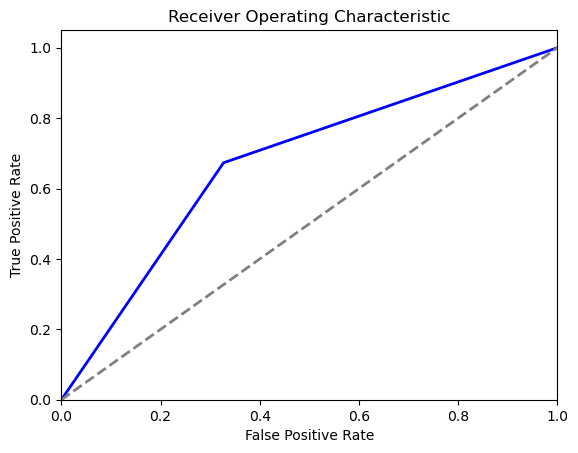

In [25]:
# Prepare the data
train_set['win_binary'] = train_set['wl_main'].apply(lambda x: 1 if x == 'W' else 0)
train_set['date_game'] = pd.to_datetime(train_set['date_game'])

team_data = train_set[train_set['team_abbreviation_main'] == team]
team_data = team_data.sort_values(by='date_game')
train_labels = train_set['win_binary']

labels = team_data['win_binary']


# Perform 5-fold cross-validation on the training set
tscv = TimeSeriesSplit(n_splits=5)
all_train_predictions = pd.Series(dtype=int)
all_train_true_labels = pd.Series(dtype=int)

for train_index, val_index in tscv.split(train_set):
    t_train_data = train_set.iloc[train_index]
    t_val_data = train_set.iloc[val_index]
    
    # Calculate moving average for the train set
    train_probabilities = historical_average(t_train_data['win_binary'], window=5).fillna(0)
    
    # Aligning predictions for the validation set from the entire sequence
    val_prob_start_idx = t_val_data.index[0]
    train_prob_tail = train_probabilities.loc[val_prob_start_idx-5:val_prob_start_idx-1]
    val_probabilities = pd.concat([train_prob_tail, t_val_data['win_binary']])
    rolling_probs = historical_average(val_probabilities, window=5).fillna(0)
    
    predictions = predict_binary_from_probability(rolling_probs[t_val_data.index], threshold=0.5)
    
    all_train_predictions = pd.concat([all_train_predictions, predictions])
    all_train_true_labels = pd.concat([all_train_true_labels, train_labels.iloc[val_index]])

# Evaluate the model on the training set
print("Evaluation on Training Set for the simple moving average model:")
evaluate_model(all_train_true_labels, all_train_predictions)